# Analyzing Stock prices

#### This project contains 4 parts:
    1.Preparation for Data cleaning. Trying to perform data cleaning on smallest file and look for potential flaws of data.
    2.Compressing and performing data cleaning process. 
    3.Creating tables and loading data. 
    4.Ploting data to get some information.


##### I wanted to broadly go through entire process and I've tried to list potential next steps that I would take to improve quality of data even further.

In [2]:
# Libraries:

import os
import csv
import psycopg2
import numpy as np
import pandas as pd
from scipy import stats
from io import StringIO
from tabulate import tabulate
import matplotlib.pyplot as plt

# I. Perform ETL process:
- #### 1. Preparing data cleaning Process.
- #### 2. Performing this process over all files.
- #### 3. Loading data to a database.

## 1. Preparing data cleaning Process.

I obtained data from https://stooq.com/db/h/ and downloaded from cell ["U.S.","daily"]

### I. File preparation:
 - I want to merge all contents of each folder into newly created file.
 - I changed file format into CSV, because I'm way more likely to encounter it as a Data Engineer.
 - Below i check some basic information to inspect a file.

In [5]:
folder_path = [
    "C:/Users/paha3/Desktop/us/nasdaq etfs",
    "C:/Users/paha3/Desktop/us/nasdaq stocks",
    "C:/Users/paha3/Desktop/us/nyse etfs",
    "C:/Users/paha3/Desktop/us/nyse stocks"
]

file_destination = [
    "C:/Users/paha3/Desktop/us/nasdaqetfs.txt",
    "C:/Users/paha3/Desktop/us/nasdaqstocks.txt",
    "C:/Users/paha3/Desktop/us/nyseetfs.txt",
    "C:/Users/paha3/Desktop/us/nysestocks.txt"
]

# Get a list of full file paths in the folder
def get_file_list(folder_path):
    file_list = [os.path.join(folder_path, file_name) for file_name in os.listdir(folder_path)]
    return file_list

def merge_files(file_list, output_file):
    count = 0
    try:
        with open(output_file, "w") as output:
            for file_name in file_list:
                with open(file_name, "r") as input_file:
                    output.write(input_file.read())
                    count += 1
        print(f"Merged {count} files into {output_file}")
    except Exception as e:
        print(f"An error occurred: {str(e)}")

for i in range(len(folder_path)):
    merge_files(get_file_list(folder_path[i]), file_destination[i])

Merged 365 files into C:/Users/paha3/Desktop/us/nasdaqetfs.txt
Merged 4807 files into C:/Users/paha3/Desktop/us/nasdaqstocks.txt
Merged 2173 files into C:/Users/paha3/Desktop/us/nyseetfs.txt
Merged 3687 files into C:/Users/paha3/Desktop/us/nysestocks.txt


In [44]:
csv_files = [
    "C:/Users/paha3/Desktop/Python/nasdaqetfs.csv",
    "C:/Users/paha3/Desktop/Python/nasdaqstocks.csv",
    "C:/Users/paha3/Desktop/Python/nyseetfs.csv",
    "C:/Users/paha3/Desktop/Python/nysestocks.csv"
]

df = pd.read_csv(csv_files[0])
df.head()

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>
0,AADR.US,D,20100721,000000,23.1646,23.1646,22.7969,22.7969,45503.680330826,0
1,AADR.US,D,20100722,000000,23.4621,23.4621,23.1929,23.3129,18940.045746928,0
2,AADR.US,D,20100723,000000,23.5713,23.5713,23.1471,23.3324,9345.9703923893,0
3,AADR.US,D,20100726,000000,23.4426,23.4426,23.2768,23.4153,20422.52415713,0
4,AADR.US,D,20100727,000000,23.3031,23.3411,23.2603,23.3411,8882.5677358118,0


### II. Columns and NaN values:
 - Removing redundant columns.
 - Removing "<", ">" signs.
 - Checking for missing(NaN) values.

In [45]:
df.drop(["<PER>", "<TIME>", "<OPENINT>"], axis=1, inplace=True)
df.head()

,<TICKER>,<DATE>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,AADR.US,20100721,23.1646,23.1646,22.7969,22.7969,45503.680330826
1,AADR.US,20100722,23.4621,23.4621,23.1929,23.3129,18940.045746928
2,AADR.US,20100723,23.5713,23.5713,23.1471,23.3324,9345.9703923893
3,AADR.US,20100726,23.4426,23.4426,23.2768,23.4153,20422.52415713
4,AADR.US,20100727,23.3031,23.3411,23.2603,23.3411,8882.5677358118


In [46]:
df.columns = df.columns.str.replace("<", "").str.replace(">", "")
df.head()

,TICKER,DATE,OPEN,HIGH,LOW,CLOSE,VOL
0,AADR.US,20100721,23.1646,23.1646,22.7969,22.7969,45503.680330826
1,AADR.US,20100722,23.4621,23.4621,23.1929,23.3129,18940.045746928
2,AADR.US,20100723,23.5713,23.5713,23.1471,23.3324,9345.9703923893
3,AADR.US,20100726,23.4426,23.4426,23.2768,23.4153,20422.52415713
4,AADR.US,20100727,23.3031,23.3411,23.2603,23.3411,8882.5677358118


In [47]:
df.isnull().sum()

TICKER    0
DATE      0
OPEN      0
HIGH      0
LOW       0
CLOSE     0
VOL       0
dtype: int64

### III. Removing row duplicates and converting datatypes:
- Displaying the rows that will be removed and performing their removal.
- Changing data type.

In [48]:
# Context: 
# After running this code. Still I wasn't able to change datatype to float, of rows ["OPEN":]. 

duplicates_to_remove = df[df.duplicated(keep="first")]

print("Rows that will be removed:")
print(duplicates_to_remove)

Rows that will be removed:
          TICKER    DATE    OPEN    HIGH    LOW    CLOSE    VOL
6819    <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
10714   <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
14608   <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
16258   <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
18573   <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
...          ...     ...     ...     ...    ...      ...    ...
862423  <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
863437  <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
864397  <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
868229  <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>
870317  <TICKER>  <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>

[363 rows x 7 columns]


In [49]:
# Context:
# I've created a first copy of a df and then implemented to it, because of the warning that
# I've encountered. Basically Python didn't know whether to change a view or a copy of a df.
# So the changes would be unpredictable.

def clean_numeric_columns(df):
    df_copy = df.copy()

    for col in df_copy.columns[2:]:
        try:
            df_copy[col] = pd.to_numeric(df_copy[col], errors="coerce")
        except ValueError as e:
            print(f"Error converting column '{col}': {e}")

    df_copy.dropna(subset=df_copy.columns[2:], inplace=True)

    return df_copy

df = clean_numeric_columns(df)

In [50]:
for col in df.columns[2:]:
    max_val = df[col].max()
    min_val = df[col].min()
    print(f"Column '{col}':")
    print(f"  Maximum: {max_val}")
    print(f"  Minimum: {min_val}")

Column 'OPEN':
  Maximum: 494372.75
  Minimum: 0.381
Column 'HIGH':
  Maximum: 499164.5
  Minimum: 0.38545
Column 'LOW':
  Maximum: 468816.5
  Minimum: 0.3533
Column 'CLOSE':
  Maximum: 472930.75
  Minimum: 0.37795
Column 'VOL':
  Maximum: 700105227.85577
  Minimum: 0.0


In [51]:
for col in df.columns[2:]:
    try:
        df[col] = df[col].astype("float64")
    except ValueError as e:
        print(f"Error converting column '{col}': {e}")

In [52]:
for col in df.columns[1:2]:
    try:
        df[col] = df[col].astype("datetime64[ns]")
    except ValueError as e:
        print(f"Error converting column '{col}': {e}")

In [53]:
df.dtypes

TICKER            object
DATE      datetime64[ns]
OPEN             float64
HIGH             float64
LOW              float64
CLOSE            float64
VOL              float64
dtype: object

In [54]:
for col in df.columns[2:]:
    max_val = df[col].max()
    min_val = df[col].min()
    print(f"Column '{col}':")
    print(f"  Maximum: {max_val}")
    print(f"  Minimum: {min_val}")

Column 'OPEN':
  Maximum: 494372.75
  Minimum: 0.381
Column 'HIGH':
  Maximum: 499164.5
  Minimum: 0.38545
Column 'LOW':
  Maximum: 468816.5
  Minimum: 0.3533
Column 'CLOSE':
  Maximum: 472930.75
  Minimum: 0.37795
Column 'VOL':
  Maximum: 700105227.85577
  Minimum: 0.0


### IV. Searching for outliers and deviations:
- Checking for potential outliers and removing them.

In [55]:
df.head()


,TICKER,DATE,OPEN,HIGH,LOW,CLOSE,VOL
0,AADR.US,2010-07-21,23.1646,23.1646,22.7969,22.7969,45503.680331
1,AADR.US,2010-07-22,23.4621,23.4621,23.1929,23.3129,18940.045747
2,AADR.US,2010-07-23,23.5713,23.5713,23.1471,23.3324,9345.970392
3,AADR.US,2010-07-26,23.4426,23.4426,23.2768,23.4153,20422.524157
4,AADR.US,2010-07-27,23.3031,23.3411,23.2603,23.3411,8882.567736


In [56]:
df.describe()

,OPEN,HIGH,LOW,CLOSE,VOL
count,870991.000000,870991.000000,870991.000000,870991.000000,8.709910e+05
mean,213.718304,217.785461,209.819544,213.384755,1.417853e+06
std,6075.720403,6225.054927,5933.147875,6061.339488,1.075446e+07
min,0.381000,0.385450,0.353300,0.377950,0.000000e+00
25%,22.020400,22.130350,21.899700,22.016900,6.755000e+03
50%,33.111600,33.289000,32.906200,33.099600,3.428991e+04
75%,51.580000,51.828300,51.320000,51.564300,1.963842e+05
max,494372.750000,499164.500000,468816.500000,472930.750000,7.001052e+08


In [57]:
df = df.sort_values(by=["TICKER", "DATE"])


df = df.assign(DAILY_RETURN=df.groupby("TICKER")["CLOSE"].pct_change())
df["ABS_DAILY_RETURN"] = df["DAILY_RETURN"].abs()

topb_10 = df["DAILY_RETURN"].nlargest(10)
tops_10 = df["DAILY_RETURN"].nsmallest(10)
print(topb_10)
print(tops_10)

245417    0.494235
28551     0.489117
272135    0.381943
548783    0.333933
759142    0.327490
207476    0.297563
759140    0.276486
234863    0.273844
776248    0.269884
776255    0.222908
Name: DAILY_RETURN, dtype: float64
776249   -0.344652
245418   -0.332622
28552    -0.324570
602013   -0.311634
582497   -0.286751
759141   -0.283556
776247   -0.274084
272134   -0.272949
643152   -0.251901
225665   -0.236436
Name: DAILY_RETURN, dtype: float64


In [58]:
def replace_outliers(group):
    for i in range(len(group) - 1):
        if (group.iloc[i]["ABS_DAILY_RETURN"] > 0.2 and group.iloc[i + 1]["ABS_DAILY_RETURN"] > 0.15):
            avg_value = (group.iloc[i - 1]["CLOSE"] + group.iloc[i + 1]["CLOSE"]) / 2
            group.at[group.index[i], "CLOSE"] = avg_value
    return group

# Apply the function to each 'TICKER' group
df = df.groupby("TICKER", group_keys=False).apply(replace_outliers)

In [59]:
df = df.sort_values(by=["TICKER", "DATE"])
df = df.assign(DAILY_RETURN=df.groupby("TICKER")["CLOSE"].pct_change())


topb_10 = df["DAILY_RETURN"].nlargest(10)
tops_10 = df["DAILY_RETURN"].nsmallest(10)
print(topb_10)
print(tops_10)

548783    0.333933
207476    0.297563
234863    0.273844
776255    0.222908
47470     0.219403
776920    0.218750
136033    0.216915
780590    0.212153
728678    0.209774
501889    0.209373
Name: DAILY_RETURN, dtype: float64
602013   -0.311634
643152   -0.251901
761277   -0.231284
759148   -0.225247
211230   -0.223304
759813   -0.220142
274022   -0.219470
759157   -0.210158
211228   -0.206475
43126    -0.196629
Name: DAILY_RETURN, dtype: float64


Taking inefficient code for "replace_outliers(group)" function, making it work for less than an eternity and making it easily replicable for any column.

In [60]:
"""
def replace_outliers(group):
    for i in range(len(group) - 1):
        if (group.iloc[i]["ABS_DAILY_RETURN"] > 0.2 and group.iloc[i + 1]["ABS_DAILY_RETURN"] > 0.15):
            avg_value = (group.iloc[i - 1]["CLOSE"] + group.iloc[i + 1]["CLOSE"]) / 2
            group.at[group.index[i], "CLOSE"] = avg_value
    return group

# Apply the function to each '<TICKER>' group
df = df.groupby("TICKER", group_keys=False).apply(replace_outliers)
"""

df["ABS_DAILY_RETURN"] = df["DAILY_RETURN"].abs()

mask1 = (df["ABS_DAILY_RETURN"] > 0.2) & (df["ABS_DAILY_RETURN"].shift(-1) > 0.15)
mask2 = (df["ABS_DAILY_RETURN"] > 0.2) & (df["ABS_DAILY_RETURN"].shift(1) > 0.15)

df["AVG_CLOSE"] = (df["CLOSE"].shift(-1) + df["CLOSE"].shift(1)) / 2
df["AVG_CLOSE"] = df["AVG_CLOSE"].round(4)

df.loc[mask1 | mask2, "CLOSE"] = df["AVG_CLOSE"]
df.drop(["ABS_DAILY_RETURN", "AVG_CLOSE"], axis=1, inplace=True)

In [61]:
df = df.sort_values(by=["TICKER", "DATE"])
df = df.assign(DAILY_RETURN=df.groupby("TICKER")["CLOSE"].pct_change())


topb_10 = df["DAILY_RETURN"].nlargest(10)
tops_10 = df["DAILY_RETURN"].nsmallest(10)
print(topb_10)
print(tops_10)

548783    0.333933
207476    0.297563
234863    0.273844
776255    0.222908
47470     0.219403
776920    0.218750
136033    0.216915
780590    0.212153
728678    0.209774
501889    0.209373
Name: DAILY_RETURN, dtype: float64
602013   -0.311634
643152   -0.251901
761277   -0.231284
759148   -0.225247
211230   -0.223304
759813   -0.220142
274022   -0.219470
759157   -0.210158
211228   -0.206475
43126    -0.196629
Name: DAILY_RETURN, dtype: float64


In [62]:
def remove_outliers(df, check_column, ticker="TICKER", date="DATE"):

    df = df.sort_values(by=[ticker, date])
    df = df.assign(DAILY_CHANGE=df.groupby(ticker)[check_column].pct_change().abs())

    mask1 = (df["DAILY_CHANGE"] > 0.2) & (df["DAILY_CHANGE"].shift(-1) > 0.15)
    mask2 = (df["DAILY_CHANGE"] > 0.2) & (df["DAILY_CHANGE"].shift(1) > 0.15)

    df["AVG_VALUE"] = (df[check_column].shift(-1) + df[check_column].shift(1)) / 2

    df.loc[mask1 | mask2, check_column] = df["AVG_VALUE"]
    df.drop(["DAILY_CHANGE", "AVG_VALUE"], axis=1, inplace=True)

    return df

In [63]:
df = remove_outliers(df, "OPEN")
df = remove_outliers(df, "HIGH")
df = remove_outliers(df, "LOW")
df = remove_outliers(df, "CLOSE")

In [64]:
ticker_counts = df['TICKER'].value_counts()

min_count = ticker_counts.min()

# Find the tickers that appear the least amount of times
least_common_tickers = ticker_counts[ticker_counts == min_count]

# Print the tickers that appear the least amount of times
print("Tickers that appear the least amount of times:")
print(least_common_tickers)
df.shape

Tickers that appear the least amount of times:
IBTK.US    541
Name: TICKER, dtype: int64


(870991, 8)

In [65]:
# Even though no ticker appears to be an outlier I still will implement it, because there may be in the next files.abs

ticker_counts = df['TICKER'].value_counts()
rare_tickers = ticker_counts[ticker_counts == 1].index
filtered_df = df[~df['TICKER'].isin(rare_tickers)]

In [66]:
print("Tickers that appear the least amount of times:")
print(least_common_tickers)
df.shape

Tickers that appear the least amount of times:
IBTK.US    541
Name: TICKER, dtype: int64


(870991, 8)

## 2. Performing data cleaning process:
 - I wasn't sure how to clean data in "VOL" column. Just the pure amount of variations within this column makes it really hard to do. So it might contain invalid data.
 - Columns: "OPEN", "HIGH", "LOW", "CLOSE" were simply cleaned by checking if in one day change was greater than 20% and on the next by -15%. It is unusual to see such fluctuations with one day, especially on big stock markets like NASDAQ and NYSE. They'd rather stick to the trend that they,re following. Exact numbers might need work to look for the most optimal values.
 - Ticker values were simply cleared by removing rows that appear once.

### I. Combining all what I did in preparation process and defining functions.

In [42]:
# 1-3
def file_preparation(df):
    df.drop(["<PER>", "<TIME>", "<OPENINT>"], axis=1, inplace=True)
    df.columns = df.columns.str.replace("<", "").str.replace(">", "")
    df.isnull().sum()

    return df
###
def remove_strings(df):
    df_copy = df.copy()

    for col in df_copy.columns[2:]:
        try:
            df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')
        except ValueError as e:
            print(f"Error converting column '{col}': {e}")

    df_copy.dropna(subset=df_copy.columns[2:], inplace=True)

    df_copy.dropna(subset=df_copy.columns[2:], inplace=True)
    return df_copy
###
# 4-6
def change_datatype(df):
    for col in df.columns[2:]:
        try:
            df[col] = df[col].astype("float64")
        except ValueError as e:
            print(f"Error converting column '{col}': {e}")

    for col in df.columns[1:2]:
        try:
            df[col] = df[col].astype("datetime64[ns]")
        except ValueError as e:
            print(f"Error converting column '{col}': {e}")

    return df
###
def remove_outliers(df, check_column, ticker="TICKER", date="DATE"):

    df = df.sort_values(by=[ticker, date])
    df = df.assign(DAILY_CHANGE=df.groupby(ticker)[check_column].pct_change().abs())

    mask1 = (df["DAILY_CHANGE"] > 0.2) & (df["DAILY_CHANGE"].shift(-1) > 0.15)
    mask2 = (df["DAILY_CHANGE"] > 0.2) & (df["DAILY_CHANGE"].shift(1) > 0.15)

    df["AVG_VALUE"] = (df[check_column].shift(-1) + df[check_column].shift(1)) / 2
    df["AVG_VALUE"] = df["AVG_VALUE"].round(4)

    df.loc[mask1 | mask2, check_column] = df["AVG_VALUE"]
    df.drop(["DAILY_CHANGE", "AVG_VALUE"], axis=1, inplace=True)

    return df

def remove_ticker_outlier(df):
    ticker_counts = df['TICKER'].value_counts()
    rare_tickers = ticker_counts[ticker_counts == 1].index
    df = df[~df['TICKER'].isin(rare_tickers)]
    
    return df

def change_volume(df):
    df["VOLUME"] = df["VOL"].round(6)
    df.drop(columns=["VOL"], inplace=True)

    return df

def log_return(df):
    df['LOG_RETURN'] = df['CLOSE'].pct_change().apply(lambda x: 0 if pd.isna(x) else (round(100 * (x), 4)))
    mask = df["TICKER"] != df["TICKER"].shift()
    df.loc[mask, "LOG_RETURN"] = 0
    df = df.reset_index(drop=True)
    return df

### II. Performing process on all files that I want to add to the database.

In [43]:
csv_files = [
    "C:/Users/paha3/Desktop/Python/nasdaqetfs.csv",
    "C:/Users/paha3/Desktop/Python/nasdaqstocks.csv",
    "C:/Users/paha3/Desktop/Python/nyseetfs.csv",
    "C:/Users/paha3/Desktop/Python/nysestocks.csv"
]

for file_path in csv_files:
    df = pd.read_csv(file_path)

    df = file_preparation(df)
    df = remove_strings(df)
    df = change_datatype(df)

    df = remove_ticker_outlier(df)

    df = df.sort_values(by=["TICKER", "DATE"])
    df = df.assign(DAILY_RETURN=df.groupby("TICKER")["CLOSE"].pct_change())

    df = remove_outliers(df, "OPEN")
    df = remove_outliers(df, "HIGH")
    df = remove_outliers(df, "LOW")
    df = remove_outliers(df, "CLOSE")

    df = df.sort_values(by=["TICKER", "DATE"])
    df = df.assign(DAILY_RETURN=df.groupby("TICKER")["CLOSE"].pct_change().round(6))
    df = df[df['DAILY_RETURN'] <= 0.9]      # To remove data from stock conslidation

    df = log_return(df)

    df = change_volume(df)
    
    df.to_csv(file_path, index=False)

## 3. Creating tables, loading data.
 - Dispersion in data in these columns is huge. One of the things that I would do next to make storing data more efficient is adding more tables to database schema to sort this data.
 Maybe by year, sector or something else to decrease redundancy.
 - **ticker = varchar(9) ==> [2-7] + "." + [1-3] == 11 characters**
!!! If implementing other stock data with different ticker rules it might require adjustment.!!!

 - **numeric == (17, 4) for open to close ==> Some stocks contain absurdly huge values. Mainly from companies that went bancrupt. There should be a first place to look for improvement and isolate bancrupt stocks.**

 - **numeric == (16, 6) for vol ==> Highest volume I've found was a number of size 10^10. On the other hand 6 decimal points are used due to small trafic for some stocks. For big stocks it feels a bit redundant.**

 - **numeric == (7, 6) for daily_return ==> There is no point to store bigger numbers and 6 decimal points, because I feel like it.**

### I. Creating tables and choosing data types.

In [5]:
db_params = {
    "database" : "stocks",
    "user"     : "postgres",
    "password" : "qwerQWER",
    "host"     : "localhost",
    "port"     : '5433'
}

conn = psycopg2.connect(**db_params)
conn.close()

def transaction_commit(transaction_commit):
    conn = psycopg2.connect(**db_params)
    cur = conn.cursor()

    cur.execute(transaction_commit)
    conn.commit()
    conn.close()

In [44]:
nasdaq_stock_table = """
    CREATE TABLE nasdaq_stocks
    (
        id            serial PRIMARY KEY,
        ticker        varchar(11),
        date          date, 
        open          numeric(17, 4),
        high          numeric(17, 4),
        low           numeric(17, 4),
        close         numeric(17, 4),
        daily_return  numeric(7, 6),
        log_return    numeric(9, 4),
        volume        numeric(16, 6)
    );
"""


nasdaq_etf_table = """
    CREATE TABLE nasdaq_etf
    (
        id            serial PRIMARY KEY,
        ticker        varchar(11),
        date          date, 
        open          numeric(17, 4),
        high          numeric(17, 4),
        low           numeric(17, 4),
        close         numeric(17, 4),
        daily_return  numeric(7, 6),
        log_return    numeric(9, 4),
        volume        numeric(16, 6)
    );
"""


nyse_stock_table = """
    CREATE TABLE nyse_stocks
    (
        id            serial PRIMARY KEY,
        ticker        varchar(11),
        date          date, 
        open          numeric(17, 4),
        high          numeric(17, 4),
        low           numeric(17, 4),
        close         numeric(17, 4),
        daily_return  numeric(7, 6),
        log_return    numeric(9, 4),
        volume        numeric(16, 6)
    );
"""


nyse_etf_table = """
    CREATE TABLE nyse_etf
    (
        id            serial PRIMARY KEY,
        ticker        varchar(11),
        date          date, 
        open          numeric(17, 4),
        high          numeric(17, 4),
        low           numeric(17, 4),
        close         numeric(17, 4),
        daily_return  numeric(7, 6),
        log_return    numeric(9, 4),
        volume        numeric(16, 6)
    );
"""

transaction_commit(nasdaq_stock_table)
transaction_commit(nyse_stock_table)
transaction_commit(nasdaq_etf_table)
transaction_commit(nyse_etf_table)

### II. Loading data to database.

In [45]:
csv_files = [
    "C:/Users/paha3/Desktop/Python/nasdaqetfs.csv",
    "C:/Users/paha3/Desktop/Python/nasdaqstocks.csv",
    "C:/Users/paha3/Desktop/Python/nyseetfs.csv",
    "C:/Users/paha3/Desktop/Python/nysestocks.csv"
]

table_names = [
    "nasdaq_etf",
    "nasdaq_stocks",
    "nyse_etf",
    "nyse_stocks"
]


try:
    connection = psycopg2.connect(**db_params)
    cursor = connection.cursor()

    for i, csv_file in enumerate(csv_files):
        table_name = table_names[i]
    
        with open(csv_file, 'r') as file:
            reader = csv.reader(file)
            next(reader)  

            data_buffer = StringIO()
            data_writer = csv.writer(data_buffer)
            
            for row in reader:

                reordered_row = [row[0], row[1], row[2], row[3], row[4], row[5], row[6], row[7], row[8]]
                
                data_writer.writerow(reordered_row)
            

            data_buffer.seek(0)
            
 
            columns = ['ticker', 'date', 'open', 'high', 'low', 'close', 'daily_return', 'log_return', 'volume']
            cursor.copy_expert(f"COPY {table_name} ({', '.join(columns)}) FROM stdin WITH CSV", data_buffer)

        connection.commit()

    cursor.close()
    connection.close()

    print("Data loaded successfully.")
except Exception as e:
    print(f"An error occurred: {str(e)}")

Data loaded successfully.


# II. Ploting data.

In [46]:
def transaction_block(query):
    conn = psycopg2.connect(**db_params)
    cur = conn.cursor()

    cur.execute(query)
    result = cur.fetchall()
    conn.commit()
    conn.close()

    return result

C:\Users\paha3\AppData\Local\Temp\ipykernel_19512\3501453520.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


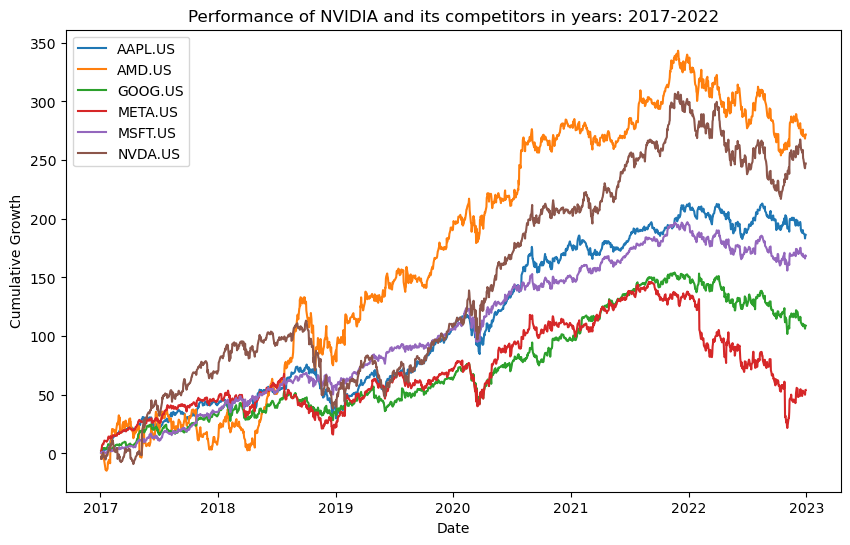

In [6]:
conn = psycopg2.connect(**db_params)

query = """
SELECT ticker, date, log_return
FROM nasdaq_stocks
WHERE ticker IN ('MSFT.US', 'GOOG.US', 'NVDA.US', 'AAPL.US', 'AMD.US', 'META.US')
    AND date >= '2017-01-01' 
    AND date <= '2022-12-31'
ORDER BY ticker, date;
"""

df = pd.read_sql(query, conn)

# Close the database connection after retrieving the data
conn.close()

# Create an area graph using Matplotlib
df['cumulative_growth'] = df.groupby('ticker')['log_return'].cumsum()

# Create a line graph to visualize cumulative growth
fig, ax = plt.subplots(figsize=(10, 6))

for ticker, group in df.groupby("ticker"):
    ax.plot(group["date"], group["cumulative_growth"], label=ticker)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Growth")
ax.set_title("Performance of NVIDIA and its competitors in years: 2017-2022")
ax.legend()

plt.show()

C:\Users\paha3\AppData\Local\Temp\ipykernel_19512\2030899723.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


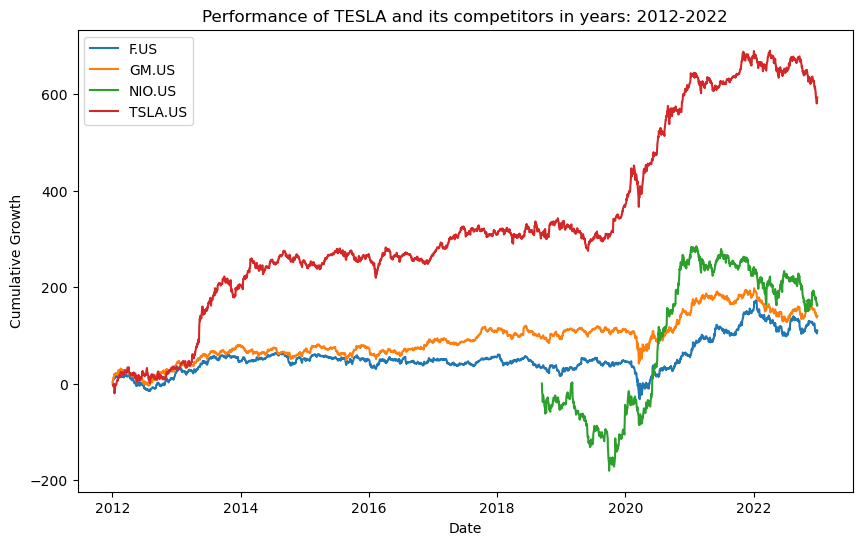

In [7]:
conn = psycopg2.connect(**db_params)

query = """
SELECT ticker, date, log_return
FROM nasdaq_stocks
WHERE ticker = 'TSLA.US'
    AND date >= '2012-01-01' 
    AND date <= '2022-12-31'
UNION ALL
SELECT ticker, date, log_return
FROM nyse_stocks
WHERE ticker IN ('F.US', 'GM.US', 'NIO.US')
    AND date >= '2012-01-01' 
    AND date <= '2022-12-31'
ORDER BY ticker, date;
"""

df = pd.read_sql(query, conn)

# Close the database connection after retrieving the data
conn.close()

# Create an area graph using Matplotlib
df['cumulative_growth'] = df.groupby('ticker')['log_return'].cumsum()

# Create a line graph to visualize cumulative growth
fig, ax = plt.subplots(figsize=(10, 6))

for ticker, group in df.groupby("ticker"):
    ax.plot(group["date"], group["cumulative_growth"], label=ticker)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Growth")
ax.set_title("Performance of TESLA and its competitors in years: 2012-2022")
ax.legend()

plt.show()